## 23. Point Set Transformation from the Moving to the Fixed Image Domain

An elastix registration estimates a transform $T$ that maps physical points *from the fixed image domain to the moving image domain*. This is the direction needed to resample the moving image onto the fixed image grid, and it is also the direction `transformix` applies when it transforms a point set: the input points are defined in the fixed image and the output points lie in the moving image (see [Example 9](ITK_Example09_PointSetAndMaskTransformation.ipynb)).

Landmarks, contours, or regions of interest are, however, often defined in the *moving* image. Bringing them into the fixed image domain requires the *inverse* transform $T^{-1}$. This notebook shows how to do that with standard ITK tools:

1. Read and write point sets in standard file formats with `itkwasm-mesh-io`.
2. Run an elastix registration with rigid and affine stages.
3. Convert the result to an `itk.CompositeTransform` with `ElastixRegistrationMethod.ConvertToItkTransform` (see [Example 22](ITK_Example22_ConvertToITKTransform.ipynb)).
4. Invert the ITK transform.
5. Apply the inverse to an `itk.Mesh` of points with `itk.transform_mesh_filter`.
6. Validate the mapped points against corresponding landmarks that are known in the fixed image, and write them to standard file formats.

This example addresses ITKElastix issues [#123](https://github.com/InsightSoftwareConsortium/ITKElastix/issues/123) and [#135](https://github.com/InsightSoftwareConsortium/ITKElastix/issues/135). The last section discusses non-linear (B-spline) stages, which have no closed-form inverse.

In [1]:
from dataclasses import asdict

import itk
import numpy as np
import matplotlib.pyplot as plt
from itkwasm import PointSet, PointSetType
from itkwasm_mesh_io import (
    vtk_poly_data_read_point_set,
    vtk_poly_data_write_point_set,
    wasm_write_point_set,
)

%matplotlib inline

### Load the images and corresponding landmarks

The lung CT dataset ships with 51 pairs of corresponding landmarks: one set in the fixed image and one set in the moving image. The files use the elastix point set format, where the first line states that the coordinates are physical `point`s (rather than voxel `index`es) and the second line gives the number of points.

The landmarks are *not* used to drive the registration here. They serve as ground truth to check the moving-to-fixed mapping at the end.

In [2]:
fixed_image = itk.imread("data/CT_3D_lung_fixed.mha", itk.F)
moving_image = itk.imread("data/CT_3D_lung_moving.mha", itk.F)

fixed_landmarks = np.loadtxt(
    "data/CT_3D_lung_fixed_point_set_corrected.txt", skiprows=2
)
moving_landmarks = np.loadtxt(
    "data/CT_3D_lung_moving_point_set_corrected.txt", skiprows=2
)

dimension = fixed_image.GetImageDimension()
print(f"{len(fixed_landmarks)} corresponding landmark pairs in {dimension}D")

51 corresponding landmark pairs in 3D


In [3]:
def mean_distance(points_a, points_b):
    # Mean Euclidean distance between corresponding points, in physical units (mm)
    return np.linalg.norm(points_a - points_b, axis=1).mean()


print(
    "Mean distance between corresponding landmarks before registration: "
    f"{mean_distance(fixed_landmarks, moving_landmarks):.2f} mm"
)

Mean distance between corresponding landmarks before registration: 35.27 mm


### Write and read point sets in standard file formats

The elastix text format is only understood by elastix and transformix. The [itkwasm-mesh-io](https://pypi.org/project/itkwasm-mesh-io/) package reads and writes point sets in standard formats, so landmarks can be exchanged with tools such as ParaView or 3D Slicer. Supported point set formats are VTK PolyData (`.vtk`), Wavefront OBJ (`.obj`), Object File Format (`.off`), MZ3 (`.mz3`), and the ITK-Wasm format (`.iwm`, `.iwm.cbor`). Each format has a `<format>_read_point_set` and a `<format>_write_point_set` function that operate on `itkwasm.PointSet` objects. (The format-agnostic `read_point_set` and `write_point_set` functions of itkwasm-mesh-io 1.7.1 dispatch to a package that is not published, so the format-specific functions are used here.)

We first convert both landmark sets to VTK PolyData files.

In [4]:
def point_set_from_array(points, name):
    # Create an itkwasm.PointSet from an (N, dimension) array of physical coordinates
    points = np.asarray(points, dtype=np.float32)
    return PointSet(
        pointSetType=PointSetType(dimension=points.shape[1]),
        name=name,
        numberOfPoints=len(points),
        points=points.ravel(),
        numberOfPointPixels=0,
        pointData=np.array([], dtype=np.float32),
    )


vtk_poly_data_write_point_set(
    point_set_from_array(fixed_landmarks, "fixed landmarks"),
    "exampleoutput/CT_3D_lung_fixed_landmarks.vtk",
)
vtk_poly_data_write_point_set(
    point_set_from_array(moving_landmarks, "moving landmarks"),
    "exampleoutput/CT_3D_lung_moving_landmarks.vtk",
)

print(open("exampleoutput/CT_3D_lung_moving_landmarks.vtk").read(160))

# vtk DataFile Version 2.0
File written by itkPolyDataMeshIO
ASCII
DATASET POLYDATA
POINTS 51 float
-40.94 -47.022 -1169.5
-66.894 16.497 -1312
-98.995 -56.584 


The read functions return a flag that tells whether the file could be read, followed by the `itkwasm.PointSet`. Its `asdict` representation converts to a native `itk.PointSet` with `itk.pointset_from_dict`.

ITK mesh filters such as `itk.transform_mesh_filter` operate on `itk.Mesh` objects rather than on `itk.PointSet` objects. A mesh without cells is a point set, so we copy the points container into a mesh.

In [5]:
MeshType = itk.Mesh[itk.F, dimension]


def read_point_set_as_mesh(file_name):
    # Read a VTK PolyData point set file into an itk.Mesh without cells
    could_read, point_set = vtk_poly_data_read_point_set(file_name)
    assert could_read, f"Could not read {file_name}"
    itk_point_set = itk.pointset_from_dict(asdict(point_set))
    mesh = MeshType.New()
    mesh.SetPoints(itk_point_set.GetPoints())
    return mesh


moving_mesh = read_point_set_as_mesh("exampleoutput/CT_3D_lung_moving_landmarks.vtk")
fixed_mesh = read_point_set_as_mesh("exampleoutput/CT_3D_lung_fixed_landmarks.vtk")

print(
    f"{moving_mesh.GetNumberOfPoints()} points, first: {list(moving_mesh.GetPoint(0))}"
)

51 points, first: [-40.939998626708984, -47.02199935913086, -1169.5]


### Register the images

We run a rigid stage followed by an affine stage with the default parameter maps. Both transform types have an exact inverse. We keep a handle on the `ElastixRegistrationMethod` object because its `ConvertToItkTransform` method is needed afterwards.

In [6]:
parameter_object = itk.ParameterObject.New()
parameter_object.AddParameterMap(itk.ParameterObject.GetDefaultParameterMap("rigid"))
parameter_object.AddParameterMap(itk.ParameterObject.GetDefaultParameterMap("affine"))

registration_method = itk.ElastixRegistrationMethod.New(
    fixed_image=fixed_image,
    moving_image=moving_image,
    parameter_object=parameter_object,
    log_to_console=False,
)
registration_method.Update()

result_image = registration_method.GetOutput()
result_transform_parameters = registration_method.GetTransformParameterObject()

### Convert the elastix transform to an ITK transform

`GetCombinationTransform` returns the chain of elastix transforms that was optimized. `ConvertToItkTransform` turns it into an `itk.CompositeTransform` built from standard ITK transform types.

Note that the stages appear in the *reverse* order of the elastix parameter maps: an `itk.CompositeTransform` applies its last transform first. Like the elastix result, the composite transform maps points from the fixed image domain to the moving image domain.

In [7]:
CompositeTransformType = itk.CompositeTransform[itk.D, dimension]

forward_transform = CompositeTransformType.cast(
    registration_method.ConvertToItkTransform(
        registration_method.GetCombinationTransform()
    )
)

for index in range(forward_transform.GetNumberOfTransforms()):
    print(index, forward_transform.GetNthTransform(index).GetNameOfClass())

0 AffineTransform
1 Euler3DTransform


### Invert the ITK transform

`GetInverseTransform` returns a new transform in which every stage is inverted and the order of the stages is reversed. It returns `None` when any stage has no inverse, for example a `BSplineTransform`.

The inverse of the `Euler3DTransform` stage is reported as its generic base class, `MatrixOffsetTransformBase`. It holds the inverted rotation matrix and offset, which is all that is needed to transform points.

In [8]:
inverse_transform = forward_transform.GetInverseTransform()
assert inverse_transform is not None, "A transform stage is not invertible"
inverse_transform = CompositeTransformType.cast(inverse_transform)

for index in range(inverse_transform.GetNumberOfTransforms()):
    print(index, inverse_transform.GetNthTransform(index).GetNameOfClass())

0 MatrixOffsetTransformBase
1 AffineTransform


### Apply the inverse transform to a point set

`itk.transform_mesh_filter` applies any ITK transform to every point of a mesh, and `itk.array_from_vector_container` returns the transformed points as a NumPy array.

The moving landmarks are defined in the moving image domain, so applying the inverse transform maps them into the fixed image domain.

In [9]:
mapped_mesh = itk.transform_mesh_filter(moving_mesh, transform=inverse_transform)

mapped_landmarks = itk.array_from_vector_container(mapped_mesh.GetPoints())
print(mapped_landmarks.shape)

(51, 3)


### Validate the mapped points

The mapped moving landmarks should now lie close to the corresponding landmarks of the fixed image. The residual distance comes from the breathing deformation of the lungs, which a rigid and affine registration cannot fully capture.

In [10]:
print(
    "Mean landmark distance before registration: "
    f"{mean_distance(fixed_landmarks, moving_landmarks):.2f} mm"
)
print(
    "Mean landmark distance after mapping the moving landmarks into the fixed domain: "
    f"{mean_distance(fixed_landmarks, mapped_landmarks):.2f} mm"
)

Mean landmark distance before registration: 35.27 mm
Mean landmark distance after mapping the moving landmarks into the fixed domain: 6.38 mm


Two more checks confirm that the transforms are consistent. Applying the forward transform to the mapped points must return the original moving landmarks, and the forward ITK transform must agree with `transformix`, which applies the elastix transform to a mesh in memory (see [Example 16](ITK_Example16_Transformix_mesh_TranslationTransform.ipynb)).

In [11]:
# Round trip: forward(inverse(p)) should return the original moving landmarks
round_trip_mesh = itk.transform_mesh_filter(mapped_mesh, transform=forward_transform)
round_trip_landmarks = itk.array_from_vector_container(round_trip_mesh.GetPoints())
print(
    f"Max round trip error: {np.abs(round_trip_landmarks - moving_landmarks).max():.2e} mm"
)

# Cross-check: transformix applies the forward elastix transform (fixed -> moving)
transformix_filter = itk.TransformixFilter.New(moving_image)
transformix_filter.SetTransformParameterObject(result_transform_parameters)
transformix_filter.SetInputMesh(fixed_mesh)
transformix_filter.Update()
transformix_landmarks = itk.array_from_vector_container(
    transformix_filter.GetOutputMesh().GetPoints()
)

itk_forward_mesh = itk.transform_mesh_filter(fixed_mesh, transform=forward_transform)
itk_forward_landmarks = itk.array_from_vector_container(itk_forward_mesh.GetPoints())
print(
    "Max difference between transformix and the ITK forward transform: "
    f"{np.abs(transformix_landmarks - itk_forward_landmarks).max():.2e} mm"
)

Max round trip error: 1.22e-04 mm
Max difference between transformix and the ITK forward transform: 0.00e+00 mm


### Visualize

The landmarks are shown over a coronal mean intensity projection of the fixed image, in physical coordinates. Grey lines connect each moving landmark to its corresponding fixed landmark.

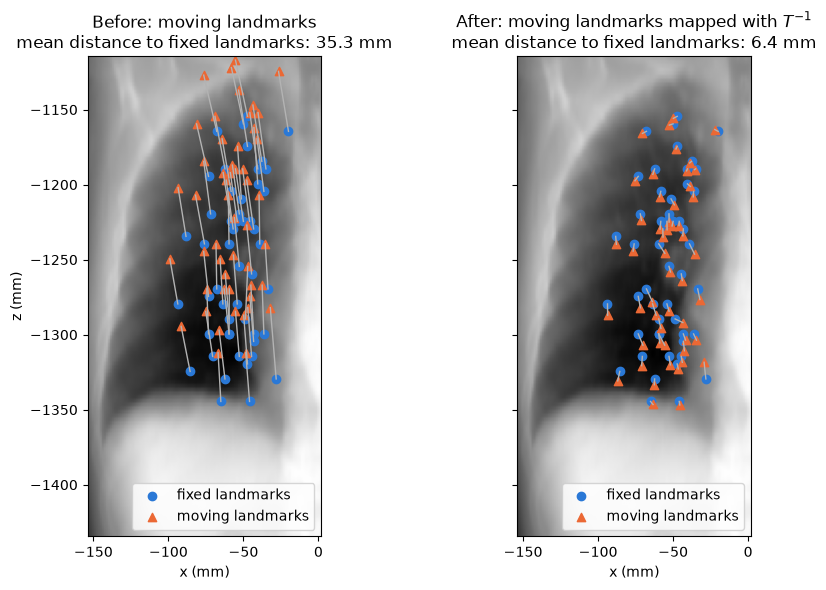

In [12]:
def coronal_projection(image):
    # Mean intensity projection along the anterior-posterior axis and its physical extent
    array = itk.array_view_from_image(image)  # indexed [z, y, x]
    projection = array.mean(axis=1)
    origin = np.array(itk.origin(image))
    upper = origin + (np.array(itk.size(image)) - 1) * np.array(itk.spacing(image))
    extent = [origin[0], upper[0], origin[2], upper[2]]  # left, right, bottom, top
    return projection, extent


projection, extent = coronal_projection(fixed_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharex=True, sharey=True)
for ax, points, title in [
    (axes[0], moving_landmarks, "Before: moving landmarks"),
    (axes[1], mapped_landmarks, "After: moving landmarks mapped with $T^{-1}$"),
]:
    ax.imshow(projection, cmap="gray", extent=extent, origin="lower")
    for fixed_point, point in zip(fixed_landmarks, points):
        ax.plot(
            [fixed_point[0], point[0]], [fixed_point[2], point[2]], color="0.7", lw=1
        )
    ax.scatter(
        fixed_landmarks[:, 0],
        fixed_landmarks[:, 2],
        s=36,
        marker="o",
        color="#2a78d6",
        label="fixed landmarks",
    )
    ax.scatter(
        points[:, 0],
        points[:, 2],
        s=36,
        marker="^",
        color="#eb6834",
        label="moving landmarks",
    )
    ax.set_title(
        f"{title}\nmean distance to fixed landmarks: "
        f"{mean_distance(fixed_landmarks, points):.1f} mm"
    )
    ax.set_xlabel("x (mm)")
    ax.legend(loc="lower right")
axes[0].set_ylabel("z (mm)")
plt.tight_layout()
plt.show()

### Write the mapped point set to standard file formats

To save the mapped points, copy the mesh points into an `itk.PointSet`, convert it to an `itkwasm.PointSet` with `itk.dict_from_pointset`, and write it with the function of the desired format. Here we write VTK PolyData and the compact binary ITK-Wasm CBOR format.

In [13]:
def point_set_from_mesh(mesh, name):
    # Convert the points of an itk.Mesh into an itkwasm.PointSet
    itk_point_set = itk.PointSet[itk.F, dimension].New()
    itk_point_set.SetPoints(mesh.GetPoints())
    point_set = PointSet(**itk.dict_from_pointset(itk_point_set))
    point_set.name = name
    return point_set


mapped_point_set = point_set_from_mesh(mapped_mesh, "moving landmarks in fixed domain")

vtk_poly_data_write_point_set(
    mapped_point_set, "exampleoutput/CT_3D_lung_moving_landmarks_in_fixed_domain.vtk"
)
wasm_write_point_set(
    mapped_point_set,
    "exampleoutput/CT_3D_lung_moving_landmarks_in_fixed_domain.iwm.cbor",
)

could_read, reread_point_set = vtk_poly_data_read_point_set(
    "exampleoutput/CT_3D_lung_moving_landmarks_in_fixed_domain.vtk"
)
reread_landmarks = np.asarray(reread_point_set.points).reshape(-1, dimension)
print(
    "Max difference between the written and in-memory mapped landmarks: "
    f"{np.abs(reread_landmarks - mapped_landmarks).max():.2e} mm"
)

Max difference between the written and in-memory mapped landmarks: 0.00e+00 mm


### Save the inverse transform for other ITK pipelines

The `MatrixOffsetTransformBase` stage produced by `GetInverseTransform` cannot be instantiated by the ITK transform file readers, so a transform file written from it does not read back. To obtain a file that round-trips, invert each stage into an object of its own concrete type with `GetInverse`, and assemble the inverses in reverse order: a `CompositeTransform` applies the last transform added first.

In [14]:
typed_inverse_transform = CompositeTransformType.New()
for index in reversed(range(forward_transform.GetNumberOfTransforms())):
    stage = itk.down_cast(forward_transform.GetNthTransform(index))
    stage_inverse = type(stage).New()
    if not stage.GetInverse(stage_inverse):
        raise RuntimeError(f"{stage.GetNameOfClass()} is not invertible")
    typed_inverse_transform.AddTransform(stage_inverse)

for index in range(typed_inverse_transform.GetNumberOfTransforms()):
    print(index, typed_inverse_transform.GetNthTransform(index).GetNameOfClass())

itk.transformwrite(
    [typed_inverse_transform],
    "exampleoutput/itk_inverse_transform.h5",
    compression=True,
)

0 Euler3DTransform
1 AffineTransform


In [15]:
reloaded_transform = itk.transformread("exampleoutput/itk_inverse_transform.h5")[0]

reloaded_mesh = itk.transform_mesh_filter(moving_mesh, transform=reloaded_transform)
reloaded_landmarks = itk.array_from_vector_container(reloaded_mesh.GetPoints())
print(
    "Max difference between the reloaded and the in-memory inverse: "
    f"{np.abs(reloaded_landmarks - mapped_landmarks).max():.2e} mm"
)

Max difference between the reloaded and the in-memory inverse: 0.00e+00 mm


### Non-linear stages

A `BSplineTransform` has no closed-form inverse, so `GetInverseTransform` returns `None` for a composite transform that contains a B-spline stage. Two approaches remain for such registrations:

- Estimate the inverse with elastix, as described in section 6.1.6 of the [elastix manual](https://github.com/SuperElastix/elastix/releases/download/5.3.0/elastix-5.3.0-manual.pdf): register the fixed image onto itself with the `DisplacementMagnitudePenalty` metric, passing the forward transform parameters as the initial transform, and then set `InitialTransformParametersFileName` to `NoInitialTransform` in the resulting parameter object. The resulting transform can be converted with `ConvertToItkTransform` and applied to a mesh exactly as above, or applied directly with `transformix`.
- Sample the forward transform into a displacement field with `itk.TransformToDisplacementFieldFilter`, invert that field numerically, and wrap the result in an `itk.DisplacementFieldTransform`.

Both approaches yield an approximate inverse whose accuracy should be checked, for example with the round trip test shown above.